In [167]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, log_loss

RANDOM = 42

# 1. Mount data

In [168]:
path = kagglehub.dataset_download('laotse/credit-risk-dataset')
data_dir = Path(path)
csv_files = list(data_dir.rglob('*.csv'))
preferred = [p for p in csv_files if p.name.lower() == 'credit_risk_dataset.csv']
csv_path = preferred[0] if preferred else csv_files[0]

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

df = df.drop(columns=['duration'], errors='ignore')

In [169]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Data Summary

Датасет содержит **32 581 запись** и **12 признаков**. Общий объем занимаемой памяти — 3.0 MB. 
Данные представлены тремя типами: `int64` (5 колонок), `float64` (3 колонки) и `str` (4 колонки).

*   **person_age** — Возраст заемщика (int64)
*   **person_income** — Годовой доход заемщика (int64)
*   **person_home_ownership** — Статус владения жильем (str)
*   **person_emp_length** — Стаж работы в годах (float64)
*   **loan_intent** — Цель получения кредита (str)
*   **loan_grade** — Кредитный рейтинг, присвоенный кредитором (A - G) (str)
*   **loan_amnt** — Запрошенная сумма кредита (int64)
*   **loan_int_rate** — Процентная ставка по кредиту (float64)
*   **loan_status** — Статус кредита (0 - выплачен, 1 - дефолт) (int64)
*   **loan_percent_income** — Отношение суммы кредита к годовому доходу (float64)
*   **cb_person_default_on_file** — Исторический дефолт по данным кредитного бюро (Y/N) (str)
*   **cb_person_cred_hist_length** — Длина кредитной истории в годах (int64)

**Примечание:**
*   Целевой переменной, скорее всего, является `loan_status`.

## Preprocessing

In [170]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [171]:
df[['person_emp_length', 'loan_int_rate']].isna().sum() / df.shape[0] * 100


person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64

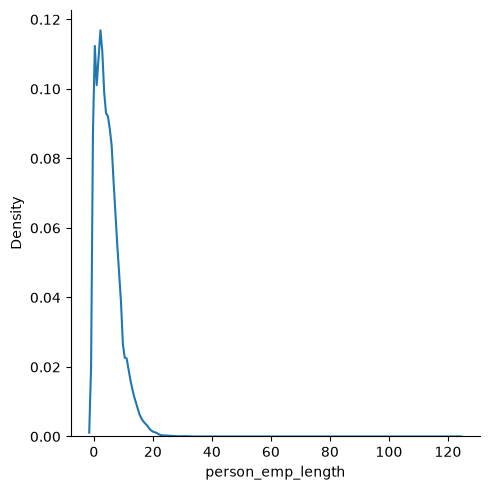

In [172]:
sns.displot(x = 'person_emp_length', data = df, kind='kde')

In [173]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())


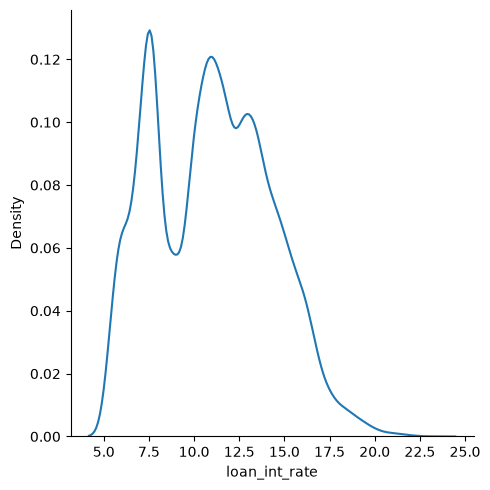

In [174]:
sns.displot(x = 'loan_int_rate', data = df, kind ='kde')

Судя про графику, распрделение мултимодальное.
Это означает, что использование простого среднего или медианы для заполнения пропусков - плохая идея, так как это сгладит пики и исказит реальную картину.

In [175]:
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))

In [176]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [177]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.013902,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.212250,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.880000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.480000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Filtration

In [178]:
df['loan_status'].unique()

array([1, 0])

In [179]:
df['loan_status'] = df['loan_status'].astype('bool')

<Axes: ylabel='person_age'>

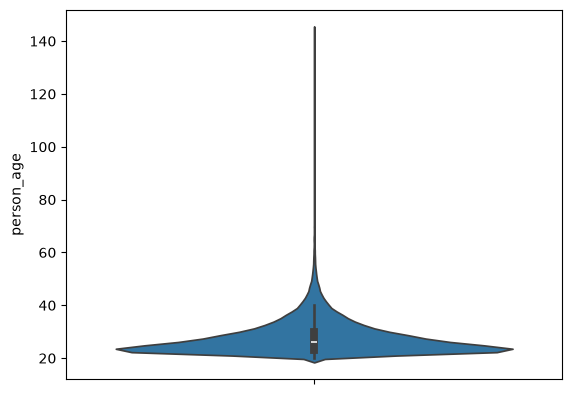

In [180]:
sns.violinplot(data=df, y='person_age')

<Axes: xlabel='person_age', ylabel='Count'>

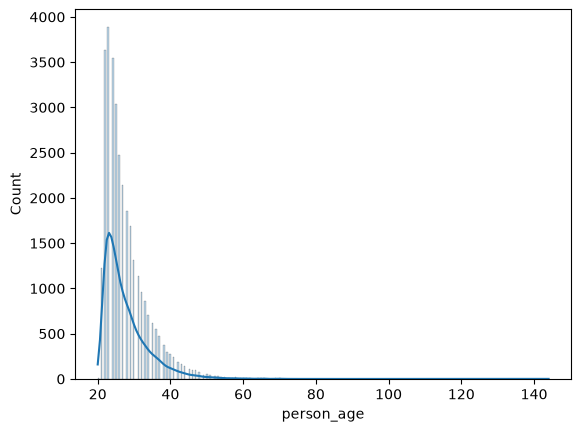

In [181]:
sns.histplot(data=df, x='person_age', kde=True, alpha = 0.3)

In [182]:
df['person_age'][df['person_age'] >= 80].count()

np.int64(8)

In [183]:
df = df[df['person_age'] < 80]

In [184]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32573.000000,3.257300e+04,32573.000000,32573.000000,32573.000000,32573.000000,32573.000000
mean,27.712676,6.588260e+04,4.767967,9589.285605,11.013779,0.170213,5.802167
std,6.179754,5.253665e+04,4.087524,6322.135503,3.212503,0.106780,4.049625
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.480000,0.230000,8.000000
max,78.000000,2.039784e+06,123.000000,35000.000000,23.220000,0.830000,30.000000


<Axes: ylabel='person_emp_length'>

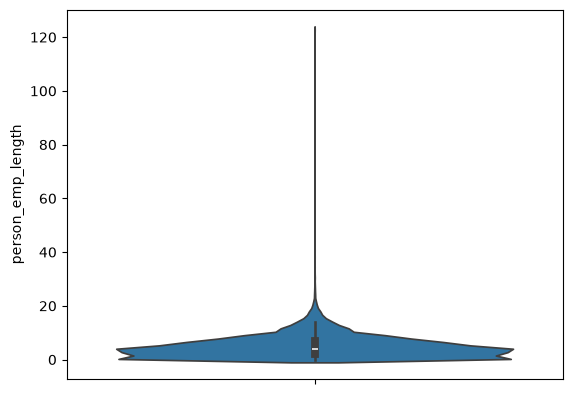

In [185]:
sns.violinplot(data=df, y='person_emp_length')

<Axes: xlabel='person_emp_length', ylabel='Count'>

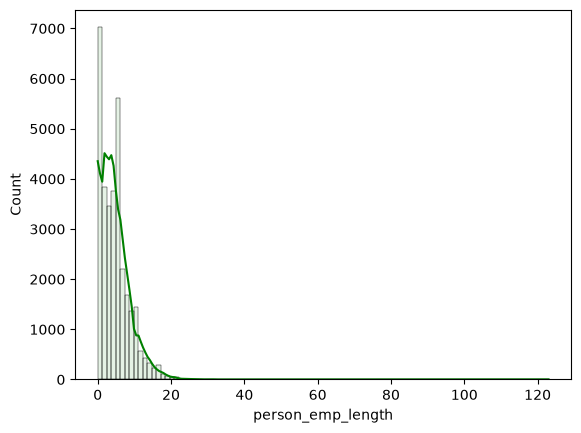

In [186]:
sns.histplot(data=df, x='person_emp_length', bins = 100, kde=True, alpha = 0.1, color='green')

In [187]:
df[['person_age', 'person_emp_length']].sort_values(by='person_emp_length', ascending=False).head(10)

,person_age,person_emp_length
0,22,123.0
210,21,123.0
32355,78,41.0
32515,53,38.0
32428,58,34.0
32263,46,31.0
30914,48,31.0
31867,46,31.0
31866,47,31.0
32539,61,30.0


In [188]:
df = df[df['person_age'] - df['person_emp_length'] >= 14]                       
df = df[df['person_age'] - df['cb_person_cred_hist_length'] >= 18]              
df = df[df['person_age'] >= 18]                                                 
df = df[df['person_income'] > 0]                                                
df = df[df['loan_amnt'] > 0]                                                    
df = df[df['loan_int_rate'] > 0]                                                
df = df[df['loan_int_rate'] < 50]                                               
df = df[df['person_income'] < 10_000_000]                                       
df = df[df['person_emp_length'] < 50]                                           
df = df[df['person_age'] < 70]                                                 

ratio = df['loan_amnt'] / df['person_income']
df = df[np.abs(ratio - df['loan_percent_income']) < 0.01]

<Axes: xlabel='person_emp_length', ylabel='Count'>

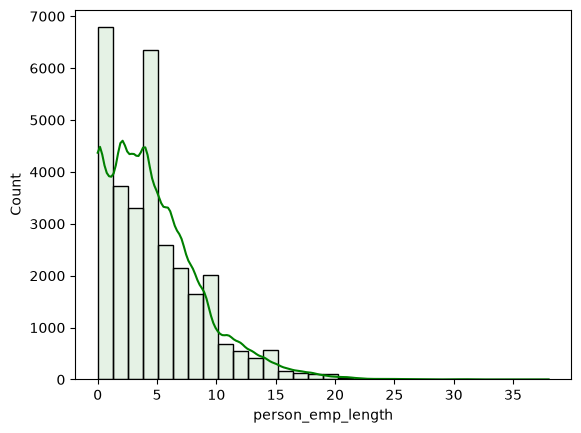

In [189]:
sns.histplot(data=df, x='person_emp_length', bins=30, kde=True, alpha=0.1, color='green')

In [190]:
df['person_emp_length'].quantile(0.99)

np.float64(17.0)

Удалять по 99 квантилю не буду т.к это выбросит самых опытных работников (стаж > 17 лет)

# 2. Exploration data analysis

**Гипотезы**

* Возраст и дефолт
Ожидается, что распределение возраста (person_age) заёмщиков без дефолта (loan_status = 0) смещено в сторону более высоких значений по сравнению с заёмщиками с дефолтом (loan_status = 1).

* Исторический дефолт и текущий статус
Наличие исторического дефолта (cb_person_default_on_file = Y) положительно связано с вероятностью текущего дефолта (loan_status = 1).

* Длина кредитной истории и риск дефолта
Ожидается отрицательная связь между длиной кредитной истории (cb_person_cred_hist_length) и вероятностью дефолта: чем длиннее кредитная история, тем ниже риск loan_status = 1.

* Доход и дефолт
Распределение годового дохода (person_income) заёмщиков без дефолта (loan_status = 0) смещено в сторону более высоких значений по сравнению с заёмщиками с дефолтом (loan_status = 1).

* Кредитный рейтинг и дефолт
Чем хуже кредитный рейтинг loan_grade (при движении от A к G), тем выше доля заёмщиков с дефолтом (loan_status = 1).

* Процентная ставка и дефолт
У заёмщиков с дефолтом (loan_status = 1) средняя и медианная процентная ставка loan_int_rate выше, чем у заёмщиков без дефолта (loan_status = 0).

* Долговая нагрузка и дефолт
Чем выше отношение суммы кредита к годовому доходу (loan_percent_income), тем выше вероятность дефолта (loan_status = 1).

* Цель кредита и дефолт
Вероятность дефолта зависит от цели кредита loan_intent: для категорий DEBTCONSOLIDATION, MEDICAL, VENTURE ожидается более высокая доля loan_status = 1, чем для EDUCATION и HOMEIMPROVEMENT.

**Баланс в таргете**

<Axes: xlabel='loan_status', ylabel='count'>

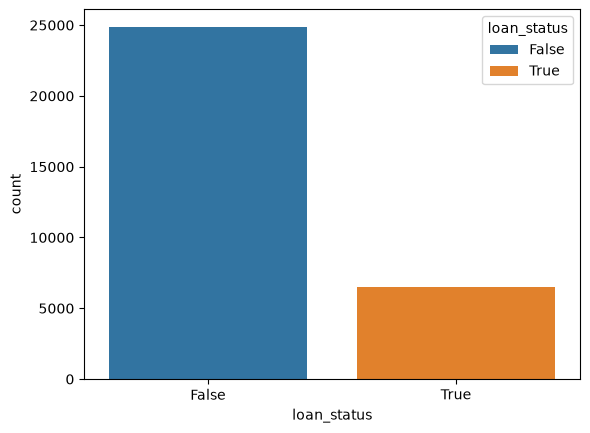

In [191]:
sns.countplot(data=df, x='loan_status', hue='loan_status')

В датасете присутствует дисбаланс классов (**нужно учитывать при выборе модели**)

### Возраст и дефолт.


Ожидается, что распределение возраста (person_age) заёмщиков без дефолта (loan_status = 0) смещено в сторону более высоких значений по сравнению с заёмщиками с дефолтом (loan_status = 1).

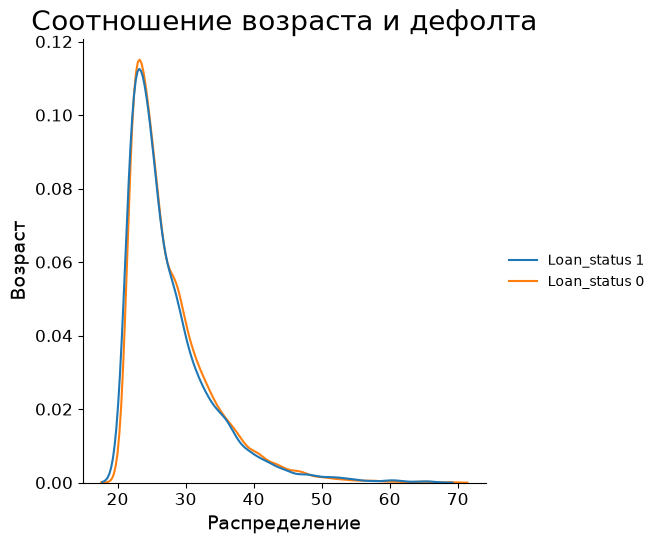

In [192]:
sns.displot({
    
    "Loan_status 1": df[df.loan_status == 1].person_age,
    "Loan_status 0": df[df.loan_status == 0].person_age
    },
    kind = 'kde',
    common_norm= False
    )
plt.title('Соотношение возраста и дефолта', fontsize = 20)
plt.xlabel('Распределение', fontsize = 14)
plt.ylabel('Возраст', fontsize = 14)

plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12);

In [193]:
df.groupby('loan_status')['person_age'].mean()

loan_status
False    27.851386
True     27.533813
Name: person_age, dtype: float64

In [194]:
df.groupby('loan_status')['person_age'].median()

loan_status
False    26.0
True     26.0
Name: person_age, dtype: float64

Различий в возрасте нету. **Гипотеза не подтвердилась**

### Исторический дефолт и текущий статус.

Наличие исторического дефолта (cb_person_default_on_file = Y) положительно связано с вероятностью текущего дефолта (loan_status = 1).

In [195]:
df['cb_person_default_on_file'].unique()

<StringArray>
['N', 'Y']
Length: 2, dtype: str

<Axes: xlabel='cb_person_default_on_file', ylabel='count'>

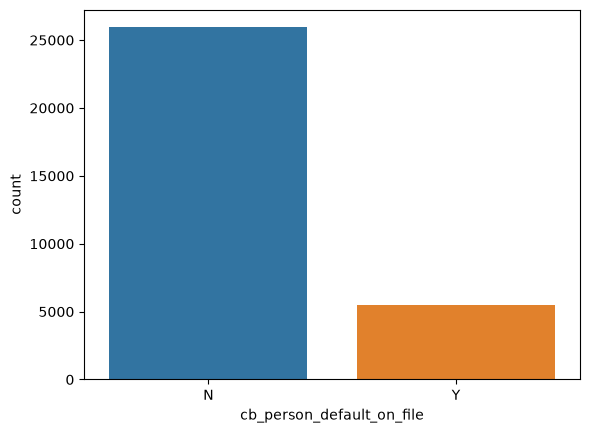

In [196]:
sns.countplot(data=df, x='cb_person_default_on_file', hue='cb_person_default_on_file')

В cb_person_default_on_file присутствует дисбаланс классов

In [197]:
df.groupby('loan_status')['cb_person_default_on_file'].value_counts()

loan_status  cb_person_default_on_file
False        N                            21355
             Y                             3508
True         N                             4572
             Y                             1964
Name: count, dtype: int64

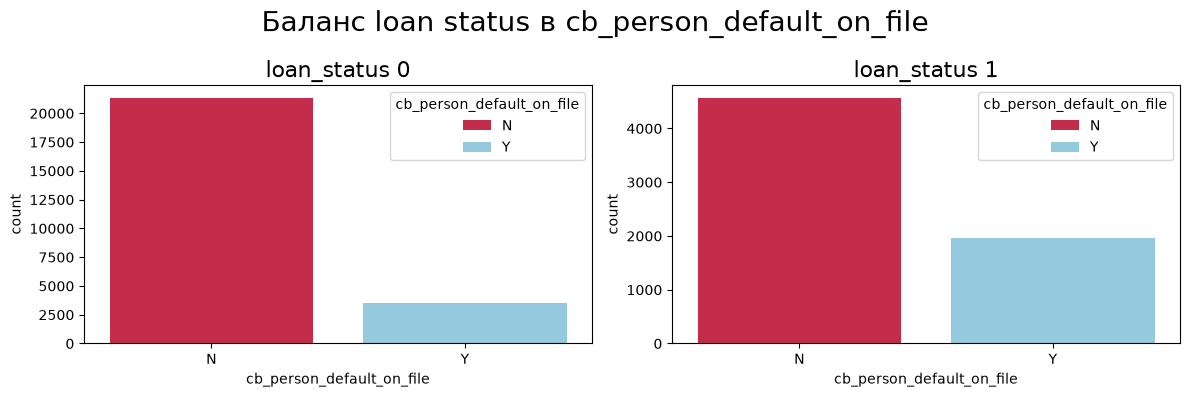

In [198]:
plt.figure(figsize=(12, 4))
plt.suptitle('Баланс loan status в cb_person_default_on_file', fontsize = 20)

plt.subplot(1, 2 , 1)
sns.countplot(data=df, x = df[df.loan_status == 0].cb_person_default_on_file,
            hue='cb_person_default_on_file', palette={'Y': 'skyblue', 'N': 'crimson'})
plt.title('loan_status 0', fontsize = 16)

plt.subplot(1, 2 , 2)
sns.countplot(data=df, x = df[df.loan_status == 1].cb_person_default_on_file,
            hue='cb_person_default_on_file', palette={'Y': 'skyblue', 'N': 'crimson'})
plt.title('loan_status 1', fontsize = 16)

plt.tight_layout();

* В обеих группах (loan_status 0 и 1) преобладают заемщики без дефолтов в прошлом (категория N). Однако распределение внутри групп сильно отличается.
* Доля заемщиков с наличием дефолта в кредитной истории (Y) среди "плохих" (loan_status 1) составляет ~30%, что более чем в 2 раза превышает аналогичную долю среди "хороших" (~14%)

**Вывод:** колонка cb_person_default_on_file явлется сильным предиктором, и хорошо влияет на целевую переменную. 

### Длина кредитной истории и риск дефолта.


Ожидается отрицательная связь между длиной кредитной истории (cb_person_cred_hist_length) и вероятностью дефолта: чем длиннее кредитная история, тем ниже риск loan_status = 1.

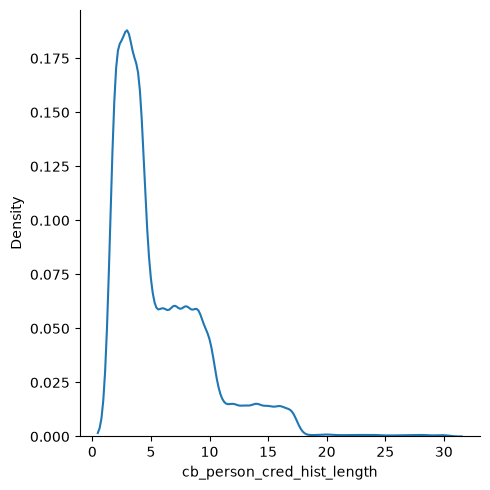

In [199]:
sns.displot(data=df, x='cb_person_cred_hist_length', kind='kde', common_norm = False);

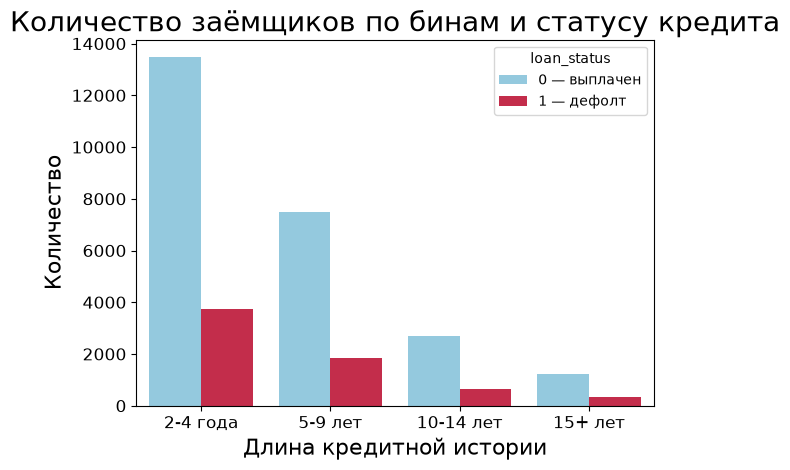

In [200]:
# 1. Создаём бины (интервалы полуоткрытые: [2,5), [5,10), [10,15), [15, ...])
df['cred_hist_bin'] = pd.cut(
    df['cb_person_cred_hist_length'],
    bins=[2, 5, 10, 15, df['cb_person_cred_hist_length'].max() + 1],
    labels=['2-4 года', '5-9 лет', '10-14 лет', '15+ лет'],
    right=False
)

sns.countplot(
    data=df,
    x='cred_hist_bin',
    hue='loan_status',
    palette={False: 'skyblue', True: 'crimson'}
)

plt.title('Количество заёмщиков по бинам и статусу кредита', fontsize=20)
plt.xlabel('Длина кредитной истории', fontsize=16)
plt.ylabel('Количество', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='loan_status', labels=['0 — выплачен', '1 — дефолт'])
plt.tight_layout();


<Axes: xlabel='loan_status', ylabel='cb_person_cred_hist_length'>

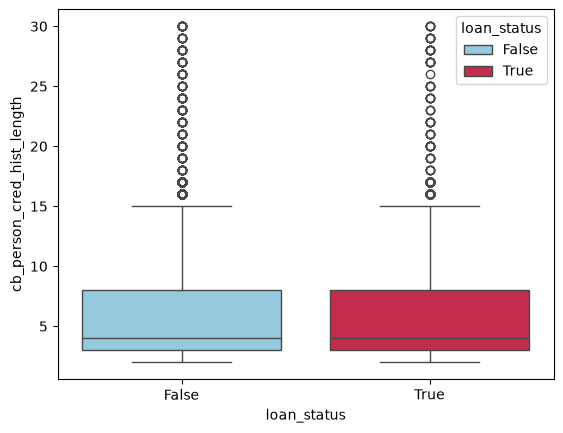

In [201]:
sns.boxplot(data=df, x = 'loan_status', y = 'cb_person_cred_hist_length',
            hue='loan_status',
            palette={False: 'skyblue', True: 'crimson'})

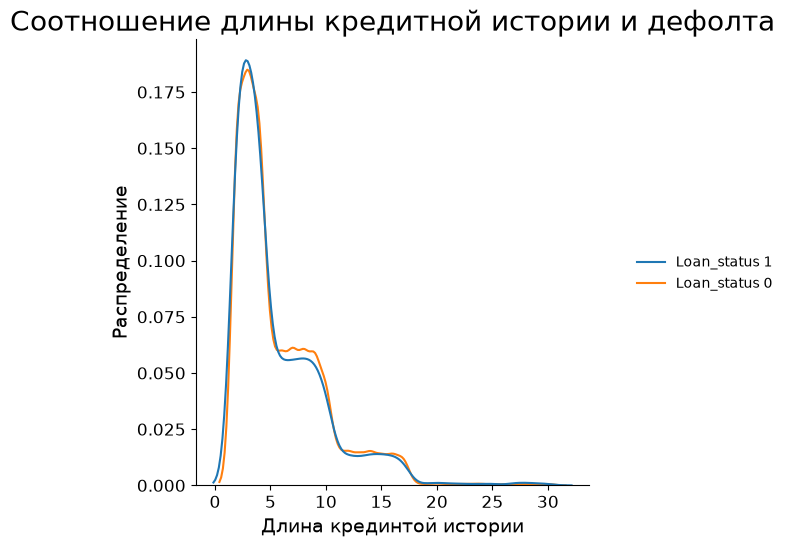

In [202]:
sns.displot({
    
    "Loan_status 1": df[df.loan_status == 1].cb_person_cred_hist_length,
    "Loan_status 0": df[df.loan_status == 0].cb_person_cred_hist_length
    },
    kind = 'kde',
    common_norm= False
    )
plt.title('Соотношение длины кредитной истории и дефолта', fontsize = 20)
plt.xlabel('Длина крединтой истории', fontsize = 14)
plt.ylabel('Распределение', fontsize = 14)

plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12);

In [203]:
df.groupby('loan_status')['cb_person_cred_hist_length'].median()

loan_status
False    4.0
True     4.0
Name: cb_person_cred_hist_length, dtype: float64

In [204]:
df.groupby('loan_status')['cb_person_cred_hist_length'].mean()

loan_status
False    5.799823
True     5.642289
Name: cb_person_cred_hist_length, dtype: float64

Значение медианы для 'Плохих' и 'хороших' заёмщиков, что опровергает гиптезу о отрицательной зависимости наличия дефолта и длины кредитной истории

### Доход и дефолт.


Распределение годового дохода (person_income) заёмщиков без дефолта (loan_status = 0) смещено в сторону более высоких значений по сравнению с заёмщиками с дефолтом (loan_status = 1).

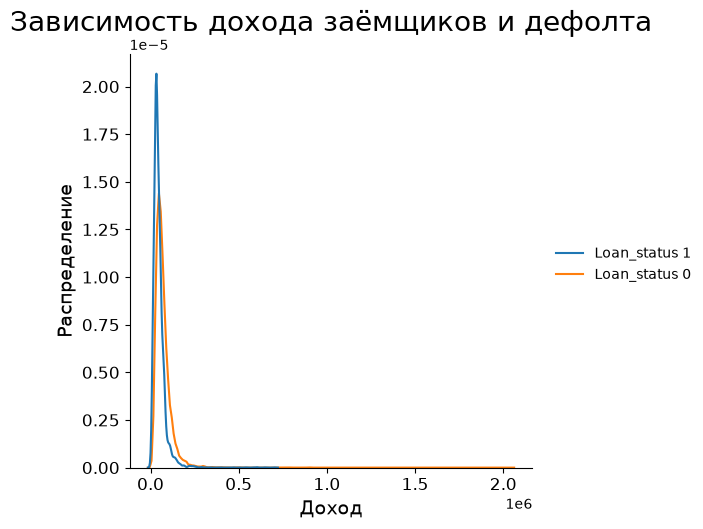

In [205]:
sns.displot({
    
    "Loan_status 1": df[df.loan_status == 1].person_income,
    "Loan_status 0": df[df.loan_status == 0].person_income
    },
    kind = 'kde',
    common_norm= False
    )
plt.title('Зависимость дохода заёмщиков и дефолта', fontsize = 20)
plt.xlabel('Доход', fontsize = 14)
plt.ylabel('Распределение', fontsize = 14)

plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12);

<Axes: xlabel='loan_status', ylabel='person_income'>

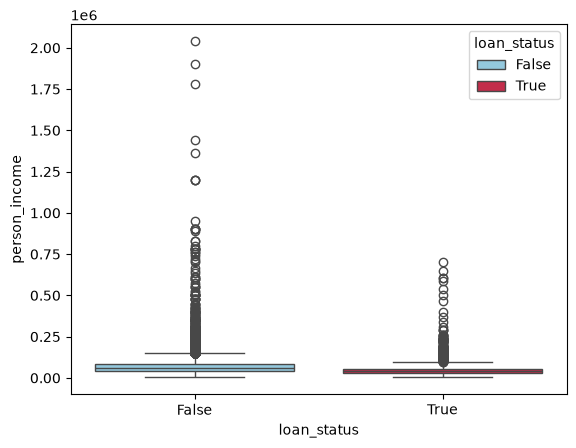

In [206]:
sns.boxplot(data=df, x = 'loan_status', y = 'person_income',
            hue='loan_status',
            palette={False: 'skyblue', True: 'crimson'})

In [207]:
df.groupby('loan_status')['person_income'].median()

loan_status
False    60000.0
True     39600.0
Name: person_income, dtype: float64

In [208]:
df.groupby('loan_status')['person_income'].mean()

loan_status
False    70815.700398
True     47549.216034
Name: person_income, dtype: float64

Судя по медиане и по среднему значению можно сделать вывод, что заёмщики с более высоким доходом с большей верюятностью будут "хорошими". Гипотеза доказана.

### Кредитный рейтинг и дефолт.

Чем хуже кредитный рейтинг loan_grade (при движении от A к G), тем выше доля заёмщиков с дефолтом (loan_status = 1).

In [209]:
df['loan_grade'].value_counts()

loan_grade
A    10503
B    10133
C     6266
D     3341
E      885
F      212
G       59
Name: count, dtype: int64

loan_grade
A    0.097877
B    0.158196
C    0.201883
D    0.567195
E    0.615819
F    0.669811
G    0.983051
Name: loan_status, dtype: float64


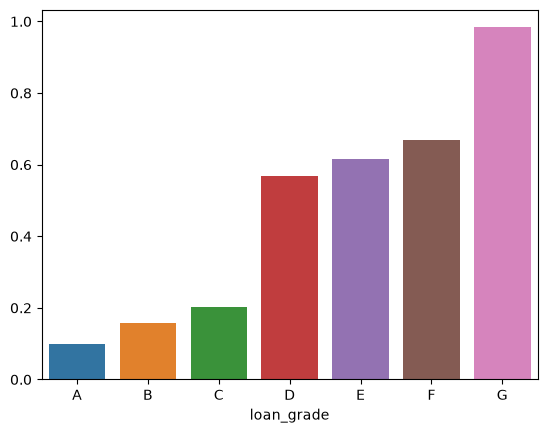

In [210]:
rate = df.groupby('loan_grade', observed=True)['loan_status'].mean()
print(rate)

sns.barplot(x=rate.index, y=rate.values, hue=rate.index);

In [211]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['loan_grade'], df['loan_status'])
chi2, p, dof, expected = chi2_contingency(ct)

print(f'chi2 = {chi2:.2f}')
print(f'p-value = {p:.2e}')
print(f'degrees of freedom = {dof}')

chi2 = 4924.16
p-value = 0.00e+00
degrees of freedom = 6


In [212]:
from scipy.stats import spearmanr

grade_order = {g: i for i, g in enumerate('ABCDEFG')}
df['grade_num'] = df['loan_grade'].map(grade_order)

rho, p_spearman = spearmanr(df['grade_num'], df['loan_status'])
print(f'Spearman rho = {rho:.3f}, p = {p_spearman:.2e}')

Spearman rho = 0.315, p = 0.00e+00


Можно заметить, что количество "плохих" заемщиков растем от A -> G. Это показывает прямую зависимость кредитного рейтинга от наличия дефолта (loan_status = 1) у заемщика.

Гипотеда доказана

### Процентная ставка и дефолт.

У заёмщиков с дефолтом (loan_status = 1) средняя и медианная процентная ставка loan_int_rate выше, чем у заёмщиков без дефолта (loan_status = 0).

In [213]:
df.groupby('loan_status')['loan_int_rate'].mean()

loan_status
False    10.448188
True     12.931404
Name: loan_int_rate, dtype: float64

In [214]:
df.groupby('loan_status')['loan_int_rate'].median()

loan_status
False    10.65
True     13.47
Name: loan_int_rate, dtype: float64

### Долговая нагрузка и дефолт.

Чем выше отношение суммы кредита к годовому доходу (loan_percent_income), тем выше вероятность дефолта (loan_status = 1).

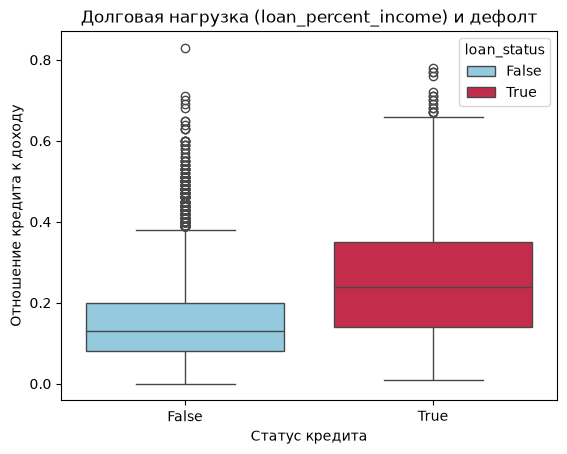

In [215]:
sns.boxplot(
    data=df, 
    x='loan_status', 
    y='loan_percent_income',
    hue='loan_status',
    palette={False: 'skyblue', True: 'crimson'}
)
plt.title('Долговая нагрузка (loan_percent_income) и дефолт')
plt.xlabel('Статус кредита')
plt.ylabel('Отношение кредита к доходу')
plt.show()

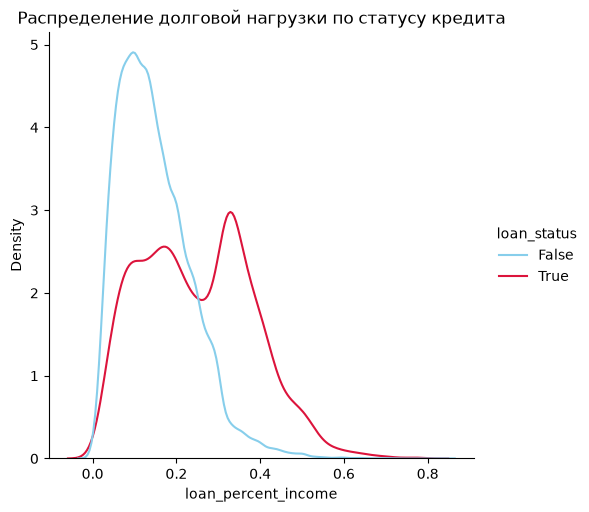

In [216]:
sns.displot(
    data=df,
    x='loan_percent_income',
    hue='loan_status',
    kind='kde',
    common_norm=False,
    palette={False: 'skyblue', True: 'crimson'}
)
plt.title('Распределение долговой нагрузки по статусу кредита')
plt.show()

percent_income_bin
0-10%     0.109819
10-20%    0.139255
20-30%    0.206659
30-40%    0.682534
40-50%    0.728469
50%+      0.783333
Name: loan_status, dtype: float64


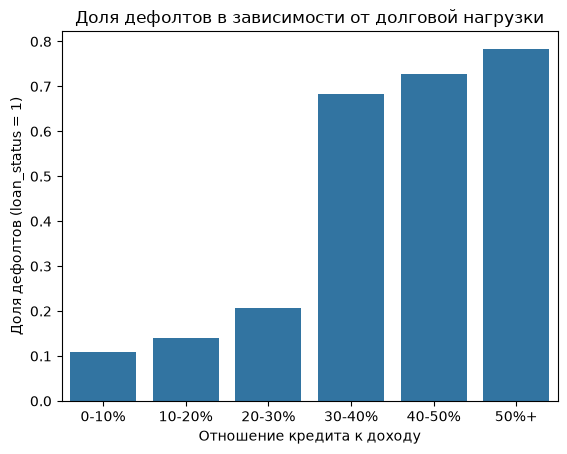

In [217]:
# Разбиваем на бины
df['percent_income_bin'] = pd.cut(
    df['loan_percent_income'], 
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']
)

# Считаем долю дефолтов в каждом бине
rate_by_income = df.groupby('percent_income_bin', observed=True)['loan_status'].mean()
print(rate_by_income)

# Строим график
sns.barplot(x=rate_by_income.index, y=rate_by_income.values)
plt.title('Доля дефолтов в зависимости от долговой нагрузки')
plt.xlabel('Отношение кредита к доходу')
plt.ylabel('Доля дефолтов (loan_status = 1)')
plt.show()

Таким образом можно заметить прямую зависимость отношения кредита к даходу и долю наступления дефолта

Гипотеза доказана

### Цель кредита и дефолт.

Вероятность дефолта зависит от цели кредита loan_intent: для категорий DEBTCONSOLIDATION, MEDICAL, VENTURE ожидается более высокая доля loan_status = 1, чем для EDUCATION и HOMEIMPROVEMENT.

In [218]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            6285
VENTURE              5578
MEDICAL              5523
PERSONAL             5387
DEBTCONSOLIDATION    5091
HOMEIMPROVEMENT      3535
Name: count, dtype: int64

Категории колонке loan_intent:
* EDUCATION - Образование
* MEDICAL - Медецина
* VENTURE - Предприятие
* PERSONAL - Личные
* DEBTCONSOLIDATION - Консолидация долга
* HOMEIMPROVEMENT - Ремонт

loan_intent
DEBTCONSOLIDATION    0.285602
EDUCATION            0.172474
HOMEIMPROVEMENT      0.258840
MEDICAL              0.217635
PERSONAL             0.196770
VENTURE              0.147185
Name: loan_status, dtype: float64


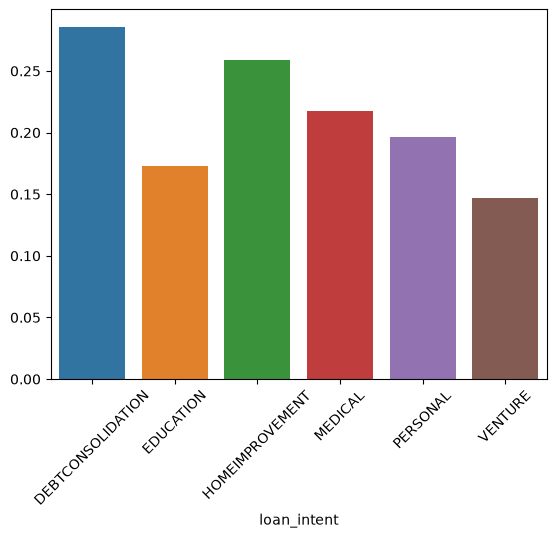

In [219]:
rate_intent = df.groupby('loan_intent', observed=True)['loan_status'].mean()
print(rate_intent)

sns.barplot(x=rate_intent.index, y=rate_intent.values, hue=rate_intent.index);
plt.xticks(rotation = 45);

Судя по гистограме, можно увидеть, что категрии DEBTCONSOLIDATION, HOMEIMPROVEMENT, PERSONAL в большей мере подвержены дефолту, нежели оставшиеся.

Самымой устойчивой к дефолту категорией стала VENTURE(предприятие), что противоречит нашей гипотезе


### Features correlation

In [220]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,grade_num
count,31399.000000,3.139900e+04,31399.000000,31399.000000,31399.000000,31399.000000,31399.000000,31399.000000
mean,27.785280,6.597256e+04,4.771012,9531.713590,10.965093,0.169827,5.767031,1.198828
std,6.146202,5.298015e+04,3.988644,6260.576788,3.189983,0.106810,4.054877,1.152764
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,23.000000,3.863550e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000,1.000000
75%,30.000000,7.967500e+04,7.000000,12000.000000,13.480000,0.230000,8.000000,2.000000
max,69.000000,2.039784e+06,38.000000,35000.000000,23.220000,0.830000,30.000000,6.000000


### Features engeneering

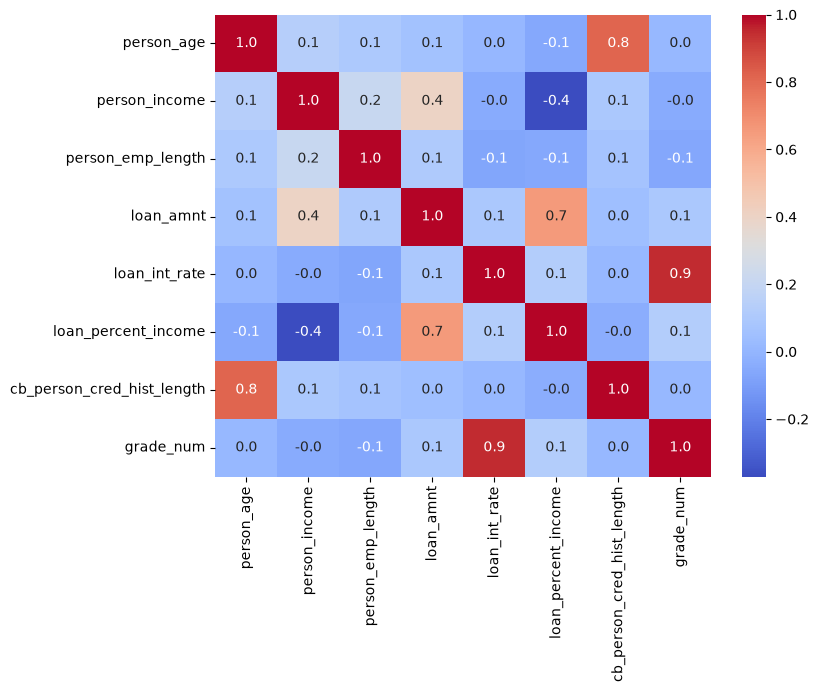

In [221]:
nums_cols = df.select_dtypes(np.number).columns

plt.subplots(figsize = (8, 6))
sns.heatmap(df[nums_cols].corr(method = 'spearman'), annot=True, fmt = '.1f', cmap='coolwarm');

| Пара | r | Решение | Комментарий |
|---|---:|---|---|
| `person_age` ↔ `cb_person_cred_hist_length` | 0.88 | Объединить или удалить один | `age_at_first_credit = person_age − cb_person_cred_hist_length`. Оба слабо связаны с таргетом. |
| `loan_int_rate` ↔ `grade_num` | 0.94 | Оставить `loan_grade` | Либо int_rate_residual=loan_int_rate−median(loan_int_rate | loan_grade)`. |
| `loan_amnt` ↔ `loan_percent_income` | 0.57 | Удалить `loan_amnt` | `loan_percent_income` уже учитывает `loan_amnt` и `person_income`. |
| `person_income` ↔ `loan_percent_income` | −0.29 | Оставить оба | Связь умеренная, взаимной информации достаточно у обоих. |

In [222]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,cred_hist_bin,grade_num,percent_income_bin
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,False,0.10,N,2,2-4 года,1,0-10%
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,True,0.57,N,3,2-4 года,2,50%+
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,True,0.53,N,2,2-4 года,2,50%+
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,True,0.25,N,2,2-4 года,0,20-30%
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,True,0.45,N,3,2-4 года,1,40-50%


In [223]:
processed_df = df.copy()

processed_df['age_at_first_credit'] = (
    processed_df['person_age'] - processed_df['cb_person_cred_hist_length'])

processed_df['int_rate_residual'] = (
    processed_df['loan_int_rate'] - processed_df.groupby('loan_grade')['loan_int_rate'].transform('median'))

processed_df = processed_df.drop(
    columns=[
        'person_age',
        'cb_person_cred_hist_length',
        'loan_amnt',
        'loan_grade',
        'loan_int_rate',
        'cred_hist_bin',
        'percent_income_bin'
    ]
)
processed_df.describe()

,person_income,person_emp_length,loan_percent_income,grade_num,age_at_first_credit,int_rate_residual
count,3.139900e+04,31399.000000,31399.000000,31399.000000,31399.000000,31399.000000
mean,6.597256e+04,4.771012,0.169827,1.198828,22.018249,-0.043222
std,5.298015e+04,3.988644,0.106810,1.152764,3.162079,0.963404
min,4.000000e+03,0.000000,0.000000,0.000000,18.000000,-10.820000
25%,3.863550e+04,2.000000,0.090000,0.000000,20.000000,-0.610000
50%,5.500000e+04,4.000000,0.150000,1.000000,21.000000,0.000000
75%,7.967500e+04,7.000000,0.230000,2.000000,23.000000,0.500000
max,2.039784e+06,38.000000,0.830000,6.000000,49.000000,3.870000


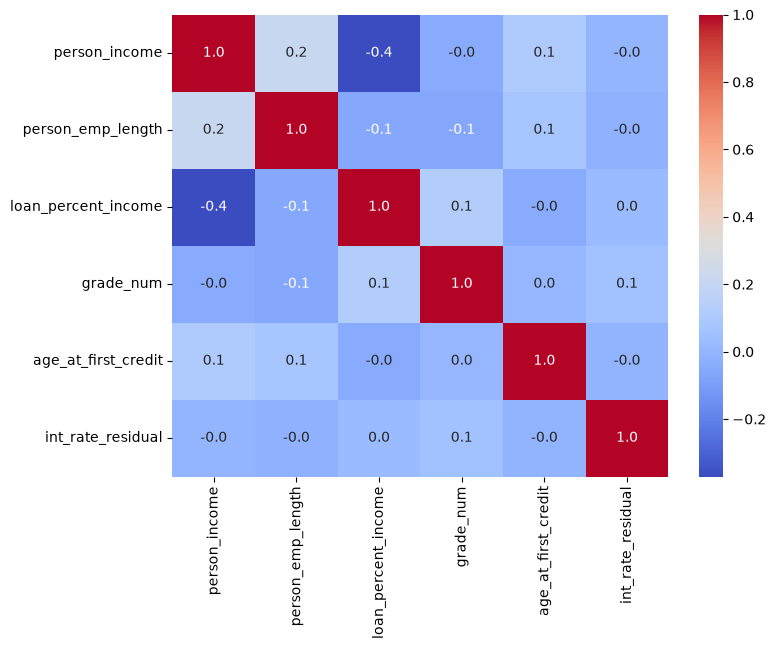

In [224]:
nums_cols = processed_df.select_dtypes(np.number).columns

plt.subplots(figsize = (8, 6))
sns.heatmap(processed_df[nums_cols].corr(method = 'spearman'), annot=True, fmt = '.1f', cmap='coolwarm');

In [225]:
processed_df.columns

Index(['person_income', 'person_home_ownership', 'person_emp_length',
       'loan_intent', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'grade_num', 'age_at_first_credit',
       'int_rate_residual'],
      dtype='str')

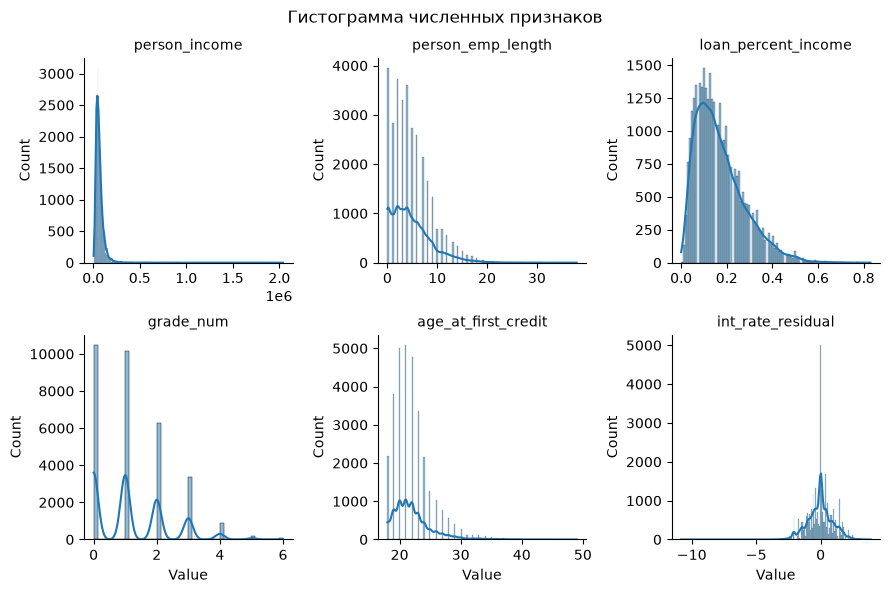

In [226]:
numeric_features = processed_df[nums_cols]
numeric_features = numeric_features.stack().reset_index().rename(
    columns={'level_1': 'Features', 0: 'Value'}
)

g = sns.FacetGrid(
    data=numeric_features,
    col='Features',
    col_wrap=3,
    sharex=False,
    sharey=False
)

g.map_dataframe(sns.histplot, x='Value', kde=True, alpha = 0.5)

g.set_titles(col_template='{col_name}')
plt.subplots_adjust(top=0.9)
plt.suptitle('Гистограмма численных признаков');

In [227]:
for col in ['person_income', 'person_emp_length', 'loan_percent_income', 'age_at_first_credit']:
    processed_df[col] = np.log1p(processed_df[col])

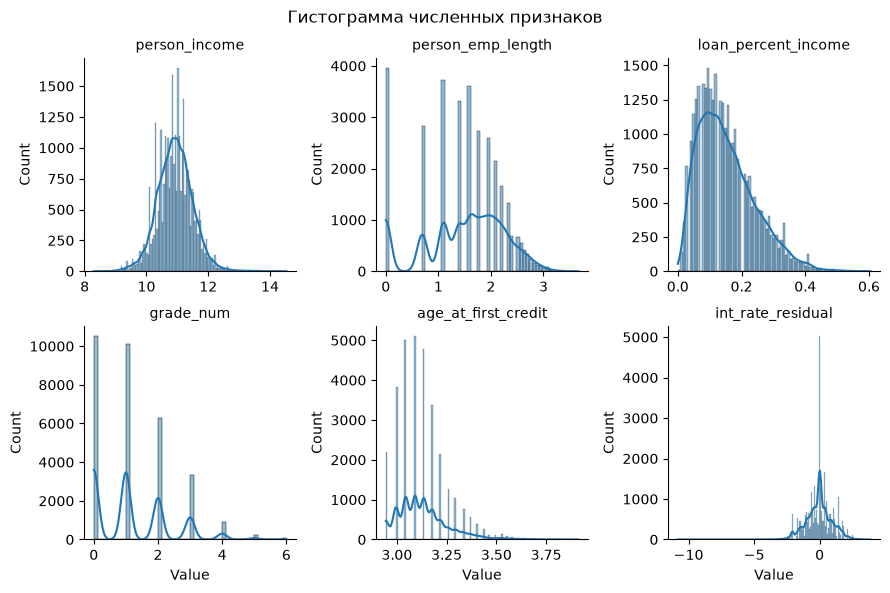

In [228]:
numeric_features = processed_df[nums_cols]
numeric_features = numeric_features.stack().reset_index().rename(
    columns={'level_1': 'Features', 0: 'Value'}
)

g = sns.FacetGrid(
    data=numeric_features,
    col='Features',
    col_wrap=3,
    sharex=False,
    sharey=False
)

g.map_dataframe(sns.histplot, x='Value', kde=True, alpha = 0.5)

g.set_titles(col_template='{col_name}')
plt.subplots_adjust(top=0.9)
plt.suptitle('Гистограмма численных признаков');

### Result

* **Дисбаланс классов** (loan_status: ~78% / ~22%). Accuracy будет обманчива — смотреть нужно на precision, recall, F1, ROC-AUC, PR-AUC.
* **Слабые признаки:** person_age и cb_person_cred_hist_length слабо различают дефолт.
* **Сильные признаки:** cb_person_default_on_file, loan_grade, person_income, loan_int_rate, loan_percent_income, loan_intent.

# 3. Model training

### Baseline

In [229]:
processed_df.head()

,person_income,person_home_ownership,person_emp_length,loan_intent,loan_status,loan_percent_income,cb_person_default_on_file,grade_num,age_at_first_credit,int_rate_residual
1,9.169623,OWN,1.791759,EDUCATION,False,0.095310,N,1,2.995732,0.15
2,9.169623,MORTGAGE,0.693147,MEDICAL,True,0.451076,N,2,3.135494,-0.61
3,11.089821,RENT,1.609438,MEDICAL,True,0.425268,N,2,3.091042,1.75
5,9.200391,OWN,1.098612,VENTURE,True,0.223144,N,0,2.995732,-0.35
6,11.252872,RENT,2.197225,EDUCATION,True,0.371564,N,1,3.178054,1.43


In [230]:
num_cols = ['person_income', 'person_emp_length', 'loan_percent_income', 'grade_num', 'age_at_first_credit', 'int_rate_residual']
cat_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

In [231]:
X = processed_df.drop(columns=['loan_status'])
y = processed_df['loan_status']

In [232]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM, test_size=0.4)

In [233]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False,
            min_frequency=10,
            drop='if_binary',       
        ), cat_cols),
    ]
)

In [234]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['person_income','person_home_ownership','person_emp_length',..., 'grade_num','age_at_first_credit','int_rate_residual']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [235]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'Precision_score: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'Logloss: {log_loss(y_test, y_pred):.4f}')

feature_names = pipe.named_steps['prep'].get_feature_names_out()
print(feature_names)

ROC-AUC: 0.8719
Precision_score: 0.4883
Recall: 0.8022
Logloss: 7.7741
['num__person_income' 'num__person_emp_length' 'num__loan_percent_income'
 'num__grade_num' 'num__age_at_first_credit' 'num__int_rate_residual'
 'cat__person_home_ownership_MORTGAGE' 'cat__person_home_ownership_OTHER'
 'cat__person_home_ownership_OWN' 'cat__person_home_ownership_RENT'
 'cat__loan_intent_DEBTCONSOLIDATION' 'cat__loan_intent_EDUCATION'
 'cat__loan_intent_HOMEIMPROVEMENT' 'cat__loan_intent_MEDICAL'
 'cat__loan_intent_PERSONAL' 'cat__loan_intent_VENTURE'
 'cat__cb_person_default_on_file_Y']


### Hyperparameter tuning

In [236]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42)),
])

parameters_grid = [
    {
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs', 'saga', 'newton-cg'],
        'clf__C': np.logspace(-3, 3, 7),
        'clf__max_iter': [1000, 2000],
    },
    {
        'clf__penalty': ['l1'],
        'clf__solver': ['saga', 'liblinear'],
        'clf__C': np.logspace(-3, 3, 7),
        'clf__max_iter': [1000, 2000],
    },
    {
        'clf__penalty': ['elasticnet'],
        'clf__solver': ['saga'],
        'clf__C': np.logspace(-3, 3, 7),
        'clf__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'clf__max_iter': [1000, 2000],
    },
]

grid_cv = GridSearchCV(
    pipe, parameters_grid,
    scoring='roc_auc',
    cv=cv,
    verbose=0,          
    n_jobs=-1,
)

In [237]:
%%time

grid_cv.fit(X_train, y_train)

CPU times: total: 5.42 s
Wall time: 21.1 s


c:\Users\sokol\OneDrive\Рабочий стол\Credit_scoring\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sokol\OneDrive\Рабочий стол\Credit_scoring\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'clf__C': array([1.e-03...e+02, 1.e+03]), 'clf__max_iter': [1000, 2000], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs', 'saga', ...]}, {'clf__C': array([1.e-03...e+02, 1.e+03]), 'clf__max_iter': [1000, 2000], 'clf__penalty': ['l1'], 'clf__solver': ['saga', 'liblinear']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_sea

In [238]:
print(f'Best estimator: {grid_cv.best_estimator_}')

Best estimator: Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['person_income',
                                                   'person_emp_length',
                                                   'loan_percent_income',
                                                   'grade_num',
                                                   'age_at_first_credit',
                                                   'int_rate_residual']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                min_frequency=10,
                                                                sparse_output=False),
                                                  ['person_hom

In [239]:
best_pipe = grid_cv.best_estimator_

y_best_pred = best_pipe.predict(X_test)
y_best_proba = best_pipe.predict_proba(X_test)[:, 1]

print(f'Best params: {grid_cv.best_params_}')
print(f'Best CV ROC-AUC: {grid_cv.best_score_:.4f}')
print(f'Test ROC-AUC:    {roc_auc_score(y_test, y_best_proba):.4f}')
print(f'Precision_score: {precision_score(y_test, y_best_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_best_pred):.4f}')
print(f'Logloss: {log_loss(y_test, y_best_pred):.4f}')


Best params: {'clf__C': np.float64(0.1), 'clf__max_iter': 1000, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Best CV ROC-AUC: 0.8694
Test ROC-AUC:    0.8720
Precision_score: 0.4884
Recall: 0.8018
Logloss: 7.7712


# 4. Analysis key features

In [240]:
import shap

In [245]:
prep = best_pipe.named_steps['prep']
clf  = best_pipe.named_steps['clf']

X_train_t = prep.transform(X_train)
X_test_t  = prep.transform(X_test)
feature_names = prep.get_feature_names_out()

masker    = shap.maskers.Independent(X_train_t)
explainer = shap.LinearExplainer(clf, masker, feature_names=feature_names)

shap_values = explainer.shap_values(X_test_t);

Background dataset has 18839 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=18839 when initializing the masker.


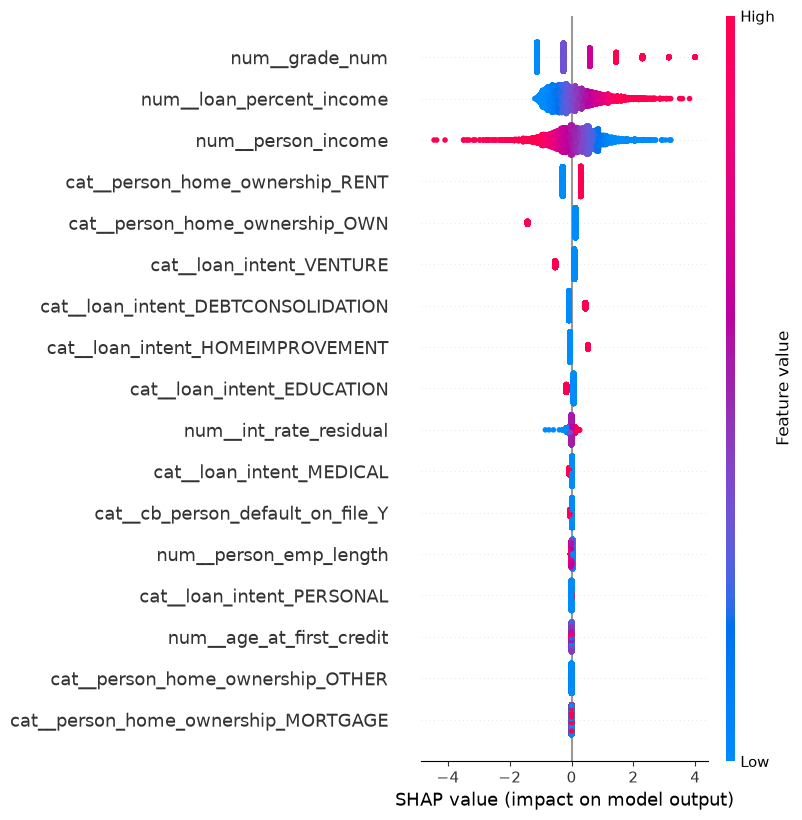

In [251]:
shap.summary_plot(shap_values, X_test_t, feature_names=feature_names);

Признаки расположены по степени их важности по оси OY, по оси OX находся значение Шепли. Каждая точка является отдельно взятым наблюдением.

Цветом обозначены значения соответствующего признака: красный - высокие, синий - низкие.

**Рассмотрим пример:**

* чем больше значение признака num_loan_percent_income, тем выше вероятность дефолта.
* чем больше значение признака num_person_income, тем ниже вероятность дефолта.

In [254]:
clf.coef_

array([[-0.72269755, -0.01557645,  0.72423787,  0.98492698, -0.00272423,
         0.07460533,  0.        ,  0.        , -1.55055612,  0.586859  ,
         0.53066929, -0.23765041,  0.58085558, -0.08866167,  0.00852222,
        -0.61517492, -0.06077598]])

In [262]:
feature_names = [name.replace('num__', '').replace('cat__', '')
                for name in prep.get_feature_names_out()]

features_imp = pd.DataFrame({
    'feature': feature_names,
    'coef':    clf.coef_[0],
})

features_imp['abs_coef'] = features_imp['coef'].abs()
features_imp = (features_imp
                .sort_values('abs_coef', ascending=False)
                .drop(columns='abs_coef')
                .reset_index(drop=True))

features_imp['direction'] = np.where(
    features_imp['coef'] > 0,
    '↑ риск дефолта',
    np.where(features_imp['coef'] < 0, '↓ риск дефолта', 'нулевой (L1)')
)

pd.set_option('display.max_rows', None)
print("Важность признаков (коэффициенты LogisticRegression)\n")
print(features_imp.to_string(index=False))

#Сколько признаков L1 занулила
zero_cnt = (features_imp['coef'] == 0).sum()
print(f"\nПризнаков всего:      {len(features_imp)}")
print(f"Занулено L1-рег.:     {zero_cnt}")
print(f"Активных признаков:   {len(features_imp) - zero_cnt}")

#Топ-3 в каждую сторону
top_pos = features_imp[features_imp['coef'] > 0].head(3)
top_neg = features_imp[features_imp['coef'] < 0].head(3)

print("\nТоп-3 признака, ПОВЫШАЮЩИХ риск дефолта:")
for _, r in top_pos.iterrows():
    print(f"  {r['feature']:<45} coef = +{r['coef']:.3f}")

print("\nТоп-3 признака, СНИЖАЮЩИХ риск дефолта:")
for _, r in top_neg.iterrows():
    print(f"  {r['feature']:<45} coef = {r['coef']:.3f}")

Важность признаков (коэффициенты LogisticRegression)

                       feature      coef      direction
     person_home_ownership_OWN -1.550556 ↓ риск дефолта
                     grade_num  0.984927 ↑ риск дефолта
           loan_percent_income  0.724238 ↑ риск дефолта
                 person_income -0.722698 ↓ риск дефолта
           loan_intent_VENTURE -0.615175 ↓ риск дефолта
    person_home_ownership_RENT  0.586859 ↑ риск дефолта
   loan_intent_HOMEIMPROVEMENT  0.580856 ↑ риск дефолта
 loan_intent_DEBTCONSOLIDATION  0.530669 ↑ риск дефолта
         loan_intent_EDUCATION -0.237650 ↓ риск дефолта
           loan_intent_MEDICAL -0.088662 ↓ риск дефолта
             int_rate_residual  0.074605 ↑ риск дефолта
   cb_person_default_on_file_Y -0.060776 ↓ риск дефолта
             person_emp_length -0.015576 ↓ риск дефолта
          loan_intent_PERSONAL  0.008522 ↑ риск дефолта
           age_at_first_credit -0.002724 ↓ риск дефолта
   person_home_ownership_OTHER  0.000000   нулевой

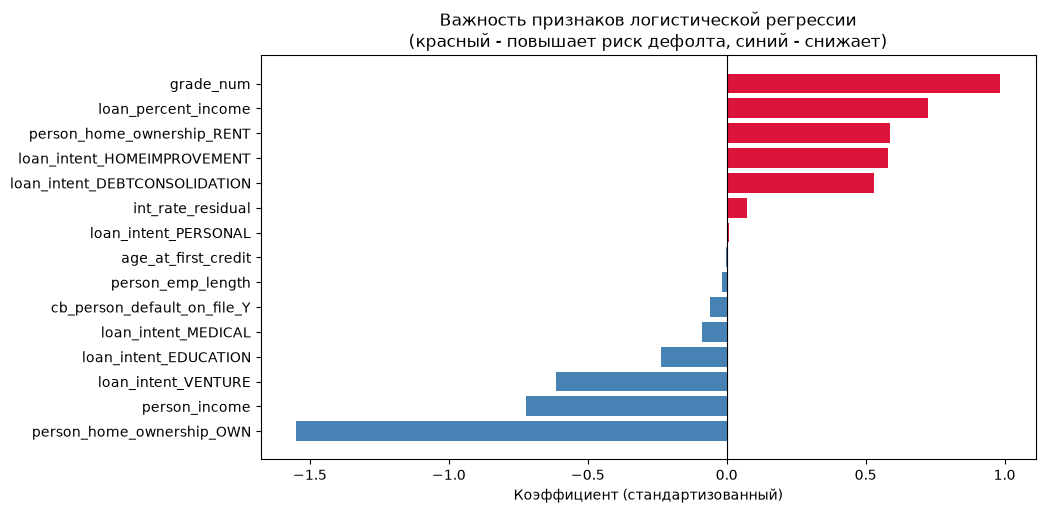

In [265]:
plot_df = features_imp[features_imp['coef'] != 0].copy()
plot_df = plot_df.sort_values('coef')

plt.figure(figsize=(10, max(5, 0.35 * len(plot_df))))
colors = ['crimson' if c > 0 else 'steelblue' for c in plot_df['coef']]
plt.barh(plot_df['feature'], plot_df['coef'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (стандартизованный)')
plt.title('Важность признаков логистической регрессии\n'
        '(красный - повышает риск дефолта, синий - снижает)');